In [1]:
from cnmf import cNMF
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import orthodb
import pycurl
from io import BytesIO
import json
import re
from collections import Counter
from sklearn.metrics import r2_score
import seaborn as sns

In [2]:
neuron_mca_directory = "neuron_cell_counts.h5ad"
palp_directory = "t005.h5ad"

In [3]:
neurons = sc.read_h5ad(neuron_mca_directory)
palp_cells = sc.read_h5ad(palp_directory)

In [4]:
palp_neurons = (palp_cells.obs['annotation'] == 'Neuron, A cell (Gr1)') | ((palp_cells.obs['annotation'] == 'Neuron, B cell (Or8)') | (palp_cells.obs['annotation'] == 'Neuron, C cell (Or49)'))

In [5]:
co2_cells = palp_cells[palp_cells.obs['annotation'] == 'Neuron, A cell (Gr1)',]
B_cells = palp_cells[palp_cells.obs['annotation'] == 'Neuron, B cell (Or8)',]
C_cells = palp_cells[palp_cells.obs['annotation'] == 'Neuron, C cell (Or49)',]

In [6]:
gaba_gene_list_palp = ["AAEL011981",
#"AAEL007542",
"AAEL000780",
"AAEL010681",
"AAEL008354",
"AAEL010710",
#"AAEL021880",
"AAEL027926",
"AAEL007372",
"AAEL010408",
"AAEL024480"]


gaba_gene_list_antenna = ["AAEL011981",
#"AAEL007542",
"AAEL000780",
"AAEL010681",
"AAEL008354",
"AAEL010710",
#"AAEL021880",
"AAEL027926",
"AAEL007372",
"AAEL010408",
"AAEL024480"]


gaba_gene_names_palp = ["Gad1",
#"Gad2",
"VGAT",
"Gat",
"Rdl",
"Lcch3",
#"Grd A",
"Grd B",
"GABA-B-R1",
"GABA-B-R2",
"GABA-B-R3"]

gaba_gene_names_antenna = ["Gad1",
#"Gad2",
"VGAT",
"Gat",
"Rdl",
"Lcch3",
#"Grd A",
"Grd B",
"GABA-B-R1",
"GABA-B-R2",
"GABA-B-R3"]

In [7]:
c02_raw_exp = co2_cells[:,gaba_gene_list_palp].layers['raw_data'].mean(axis=0)
#c02_raw_exp = c02_raw_exp[order]
b_raw_exp = B_cells[:,gaba_gene_list_palp].layers['raw_data'].mean(axis=0)
#b_raw_exp = b_raw_exp[order]
c_raw_exp = C_cells[:,gaba_gene_list_palp].layers['raw_data'].mean(axis=0)
#c_raw_exp = c_raw_exp[order]

In [8]:
co2_exp_per = (co2_cells[:,gaba_gene_list_palp].layers['raw_data'] > 1).sum(axis=0)/co2_cells.shape[0]
#co2_exp_per = co2_exp_per[order]
b_exp_per = (B_cells[:,gaba_gene_list_palp].layers['raw_data'] > 1).sum(axis=0)/B_cells.shape[0]
#b_exp_per = b_exp_per[order]
c_exp_per = (C_cells[:,gaba_gene_list_palp].layers['raw_data'] > 1).sum(axis=0)/C_cells.shape[0]
#c_exp_per = c_exp_per[order]

In [9]:
palp_raw_exp = palp_cells[palp_neurons,gaba_gene_list_palp].layers['raw_data'].mean(axis=0)
#palp_raw_exp = palp_raw_exp[order]

In [10]:
palp_exp_per = (palp_cells[palp_neurons,gaba_gene_list_palp].layers['raw_data'] > 1).sum(axis=0)/758
#palp_exp_per = palp_exp_per[order]

In [11]:
neuron_raw_exp = neurons[:,gaba_gene_list_antenna].layers['raw_data'].mean(axis=0)


In [12]:
neuron_exp_per = (neurons[:,gaba_gene_list_antenna].layers['raw_data'] > 1).sum(axis=0)/neurons.shape[0]


In [13]:
antenna_df = pd.DataFrame({'cell type': 'antenna neurons',
                           'neurotransmitter': gaba_gene_names_antenna,
                           'average transcripts per cell': neuron_raw_exp,
                           'percent of cells': neuron_exp_per*100})

In [15]:
co2_df = pd.DataFrame({'cell type': 'A cells',
                           'neurotransmitter': gaba_gene_names_palp,
                           'average transcripts per cell': c02_raw_exp,
                           'percent of cells': co2_exp_per*100})

b_df = pd.DataFrame({'cell type': 'B cells',
                           'neurotransmitter': gaba_gene_names_palp,
                           'average transcripts per cell': b_raw_exp,
                           'percent of cells': b_exp_per*100})

c_df = pd.DataFrame({'cell type': 'C cells',
                           'neurotransmitter': gaba_gene_names_palp,
                           'average transcripts per cell': c_raw_exp,
                           'percent of cells': c_exp_per*100})

In [16]:
palp_df = pd.DataFrame({'cell type': 'palp neurons',
                           'neurotransmitter': gaba_gene_names_palp,
                           'average transcripts per cell': palp_raw_exp,
                           'percent of cells': palp_exp_per*100})

In [17]:
exp_all_cells = pd.concat([co2_df,
                           b_df,
                           c_df,
                           palp_df,
                           antenna_df,
                           ],ignore_index=True)

In [18]:
bins_5 = [0,
          .5,
          1,
          1.5,
          2,
          2.5,
          3,
          3.5,
          4,
          4.5,
          5,
          max(exp_all_cells['average transcripts per cell'])]
bins_5_labels = ['0','.5','1','1.5','2','2.5','3','3.5','4','4.5','5+']
exp_all_cells['cutoff_5'] = pd.cut(exp_all_cells['average transcripts per cell'], bins_5,labels = bins_5_labels)

In [19]:
exp_all_cells

,cell type,neurotransmitter,average transcripts per cell,percent of cells,cutoff_5
0,A cells,Gad1,0.093750,0.781250,0
1,A cells,VGAT,0.429688,10.546875,0
2,A cells,Gat,0.015625,0.390625,0
3,A cells,Rdl,7.996094,89.453125,5+
4,A cells,Lcch3,0.109375,0.781250,0
5,A cells,Grd B,0.425781,2.734375,0
6,A cells,GABA-B-R1,5.480469,86.328125,5+
7,A cells,GABA-B-R2,1.097656,29.296875,1
8,A cells,GABA-B-R3,0.078125,0.390625,0
9,B cells,Gad1,0.036900,0.000000,0


In [20]:
custom_palette =sns.cubehelix_palette(start = 2, rot= 0, n_colors=11)

In [21]:
custom_palette

[[0.7764338074668017, 0.8982145133398445, 0.8009415971088042],
 [0.6796466875702348, 0.8442263851507816, 0.7127675713648596],
 [0.5887177033611721, 0.7865264317705264, 0.6285257720569012],
 [0.5036468548396135, 0.7251146531990786, 0.5482161991849287],
 [0.4244341420055591, 0.6599910494364387, 0.4718388527489426],
 [0.3550011334864599, 0.5950771891100572, 0.4033153013763936],
 [0.2871792400447748, 0.5227361474756544, 0.33458395078815834],
 [0.2252154822905939, 0.4466832806500591, 0.2697848266359092],
 [0.1691098602239171, 0.3669185886332714, 0.20891792891964617],
 [0.11886237384474461, 0.28344207142529143, 0.15198325763936943],
 [0.07447302315307625, 0.19625372902611904, 0.09898081279507877]]

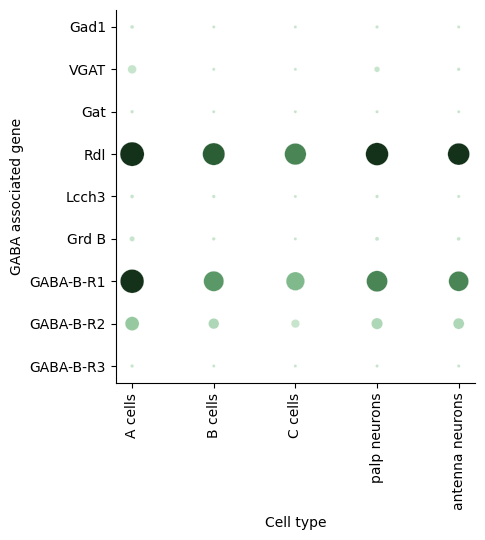

In [22]:
ax = sns.relplot(exp_all_cells,y='neurotransmitter',x='cell type',hue='cutoff_5',size='percent of cells',height=5.5, aspect=.90,
                 palette= custom_palette,sizes=(5,300),legend=None)#gridspec_kws={})
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.xlabel('Cell type')
plt.ylabel('GABA associated gene')
plt.savefig('Gaba_assoc_gene_5.svg')
plt.show()

#ax.set_xticklabels(locs=[1,3,4,5,6],labels=['a','b','c','d','e'])
#ax.set_xticklabels()
